# 🎯 Confidence-Gated RAG Agent with UQLM + LangGraph

<div style="background-color: rgba(200, 200, 200, 0.1); padding: 20px; border-radius: 8px; margin-bottom: 20px; border: 1px solid rgba(127, 127, 127, 0.2); max-width: 97.5%; overflow-wrap: break-word;">
  <p style="font-size: 16px; line-height: 1.6">
    This demo shows how to use <code>uqlm</code> inside a <a href="https://langchain-ai.github.io/langgraph/">LangGraph</a> agent so that <strong>uncertainty quantification (UQ) drives the agent's control flow</strong> rather than just being logged after the fact. The agent answers a question, scores its own confidence, and conditionally falls back to retrieval-augmented generation — or returns the answer with an explicit low-confidence caveat when neither route gives a confident answer.
  </p>
  <p style="font-size: 16px; line-height: 1.6">
    We use the white-box scorer <code>WhiteBoxUQ(scorers=["min_probability"])</code>, which reads token-level log-probabilities from the same generation call that produced the answer — so confidence scoring adds <strong>zero extra LLM calls</strong>. The key <code>uqlm</code> components used in this demo are:
  </p>

* <code>WhiteBoxUQ</code> with <code>min_probability</code> — single-generation logprob-based confidence ([Kadavath et al., 2022](https://arxiv.org/abs/2207.05221); [Lin et al., 2024](https://arxiv.org/abs/2305.19187))
* <code>UQLMNode</code> — wraps any <code>uqlm</code> scorer as an async LangGraph node

</div>

## 📊 What You'll Do in This Demo

<div style="display: flex; margin-bottom: 15px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>1</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold"><a href=#section1>Build a Wikipedia corpus and FAISS retriever</a></p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Fetch ~580 passages from 26 Wikipedia articles and index them with sentence-transformer embeddings.</p>
  </div>
</div>

<div style="display: flex; margin-bottom: 15px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>2</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold"><a href=#section2>Wrap a UQLM scorer as a LangGraph node</a></p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Drop <code>WhiteBoxUQ(min_probability)</code> into the agent's state machine via <code>make_uqlm_node()</code>.</p>
  </div>
</div>

<div style="display: flex; margin-bottom: 15px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>3</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold"><a href=#section3>Build the confidence-gated agent</a></p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Define the agent state, scoring nodes, retrieval node, and conditional edges that route on the confidence score.</p>
  </div>
</div>

<div style="display: flex; margin-bottom: 25px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>4</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold"><a href=#section4>Run example questions through all three routing paths</a></p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Walk through one well-known fact (direct path), one niche fact rescued by retrieval (RAG path), and one out-of-corpus question (caveat path).</p>
  </div>
</div>

## ⚖️ Advantages & Limitations

<div style="display: flex; gap: 20px">
  <div style="flex: 1; background-color: rgba(0, 200, 0, 0.1); padding: 15px; border-radius: 8px; border: 1px solid rgba(0, 200, 0, 0.2)">
    <h3 style="color: #2e8b57; margin-top: 0">Pros</h3>
    <ul style="margin-bottom: 0">
      <li><strong>Zero LLM-cost overhead:</strong> White-box scoring reads logprobs the model already produced — no extra calls</li>
      <li><strong>Drop-in LangGraph node:</strong> <code>make_uqlm_node()</code> works as a standard async node, no glue code</li>
      <li><strong>One number drives control flow:</strong> A single threshold separates direct, RAG-rescued, and caveated paths</li>
    </ul>
  </div>

  <div style="flex: 1; background-color: rgba(200, 0, 0, 0.1); padding: 15px; border-radius: 8px; border: 1px solid rgba(200, 0, 0, 0.2)">
    <h3 style="color: #b22222; margin-top: 0">Cons</h3>
    <ul style="margin-bottom: 0">
      <li><strong>Won't catch confident hallucinations:</strong> Layer a <code>BlackBoxUQ</code> check on the RAG branch for that</li>
      <li><strong>Needs logprob-exposing LLM:</strong> OpenAI and Vertex Gemini work; Anthropic's API does not currently expose token logprobs</li>
      <li><strong>Threshold needs tuning:</strong> 0.5 is a default, not a destination — calibrate on a labeled holdout</li>
    </ul>
  </div>
</div>

## 🧭 Architecture

![Agent workflow](../../../assets/images/langgraph_rag_agent_workflow.png)

The two `Score` nodes (highlighted in blue) are dropped-in `UQLMNode` instances — no glue code needed. The green paths return an answer the agent is confident in; the orange path attaches an explicit low-confidence caveat.

## Approximate time & cost to run this notebook

| Run type | Wall-clock | OpenAI spend |
|---|---|---|
| **First run** (downloads + indexing) | ~40–60s | **< $0.001** |
| **Subsequent runs** (caches hit) | ~15–20s | **< $0.001** |

What contributes to the first-run overhead:

- **Wikipedia download (~26 articles via the MediaWiki API):** ~15–30s, free. Cached to `wikipedia_corpus.json` after the first run.
- **`sentence-transformers/all-MiniLM-L6-v2` model download (~80 MB):** ~5–15s on first use of sentence-transformers on this machine, free. Cached by Hugging Face.
- **FAISS index build over 576 passages:** ~6s, free. Cached to `embeddings_*.npy` + `faiss_*.index`.
- **3 example questions through the agent:** ~6–10s of LLM latency, ~$0.0004 in `gpt-4o-mini` spend (~1.7K tokens total).

Why the LLM cost is essentially free: we use **`WhiteBoxUQ` with `min_probability`**, a logprob-only score derived from the *same* generation that produces the answer. Each scoring node = **1 LLM call**, not N + 1 like consistency-based scorers. If you swap in `BlackBoxUQ` or `WhiteBoxUQ(scorers=["semantic_negentropy"])` you'll pay ~4–8× more per scoring node — still tiny in absolute terms (cents per hundred queries), but worth knowing.

## Setup

In [1]:
# Uncomment if needed:
# %pip install uqlm langgraph langchain-openai python-dotenv \
#              sentence-transformers faiss-cpu requests

In [2]:
from typing import List, TypedDict

from dotenv import find_dotenv, load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

from uqlm import WhiteBoxUQ
from uqlm.integrations.langgraph import make_uqlm_node

load_dotenv(find_dotenv())  # expects OPENAI_API_KEY in your .env


True

We default to `gpt-4o-mini` because it returns token log-probabilities, which the white-box scorer needs. Any LangChain `BaseChatModel` that exposes logprobs works (e.g. OpenAI, Vertex Gemini).

We use `temperature=0` so that responses — and therefore the min-token probabilities — are reproducible across runs. White-box scoring does not require sampling, so a deterministic generation is the right default for a demo.

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 1. Wikipedia corpus + FAISS retriever

We pull a fixed set of 26 Wikipedia articles via the MediaWiki API, chunk them
into ~300-word passages (~576 passages total), and build a FAISS index over
sentence-transformer (`all-MiniLM-L6-v2`) embeddings. Embeddings and the index
are cached on disk so first-run encoding is paid once.

The corpus and retriever live in [`corpus.py`](corpus.py) and
[`retriever.py`](retriever.py) next to this notebook — you can read them as a
reference for what a minimal "real" RAG stack looks like. To use a different
corpus, swap `load_corpus()` for your own document loader; the rest of the
agent doesn't change.

In [4]:
from corpus import load_corpus
from retriever import Retriever

CORPUS = load_corpus()  # downloads on first run; cached thereafter
print(f"Corpus: {len(CORPUS)} passages across "
      f"{len({d['title'] for d in CORPUS})} Wikipedia articles")


Corpus: 576 passages across 25 Wikipedia articles


In [ ]:
# First call builds the FAISS index (~5s for 576 passages). Subsequent calls
# load the cached index in milliseconds.
retriever = Retriever(CORPUS)


def retrieve(query: str, k: int = 2) -> List[dict]:
    """Return the top-k passages by cosine similarity to ``query``.

    Each result is a dict with keys: id, title, text, score (float in [-1, 1]).
    """
    return retriever.search(query, k=k)


## 2. The UQLM scorer wrapped as a LangGraph node

We use `WhiteBoxUQ` with the `min_probability` scorer — the minimum token
probability across the generated response. This is a single-generation,
logprob-only score:

- **Zero extra LLM calls.** The score is derived from the logprobs of the very
  same generation that produced the answer. Compared to consistency-based
  scorers like `BlackBoxUQ`, which need N additional samples per scoring step,
  this is essentially free.
- **Intuitive scale.** `min_probability` is in `[0, 1]`. Low values mean the
  model hit at least one token it was unsure about — a strong signal that
  something in the answer may be wrong.
- **Tradeoff.** A model that is confidently *wrong* (high probability on a
  hallucinated token) will not be caught by this scorer alone. For maximum
  hallucination recall, combine with a sampling-based scorer (see the closing
  section). For most production agents the cost/recall trade-off favors a
  white-box gate as the first line of defense.

`make_uqlm_node(scorer, ...)` returns an async function that LangGraph can call
as a node. When the node fires, it:

1. reads the prompt from `state[prompt]` (the `prompt` key is configurable),
2. calls `scorer.generate_and_score(...)` to produce a primary answer and
   compute logprob-based scores in one shot,
3. writes the payload `{"scores": {...}, "responses": [primary], "scorer": "WhiteBoxUQ"}`
   into `state[output_key]`.

We create two `UQLMNode`s sharing the same scorer — one for the direct path,
one for the RAG path — so both attempts are visible in the final trace.

In [ ]:
wb_uq = WhiteBoxUQ(
    llm=llm,
    scorers=["min_probability"],  # logprob-only, no extra LLM calls per score
    max_calls_per_min=125,
)

# num_responses=1 means a single generation per node (the primary answer).
# WhiteBoxUQ only samples additional responses when a sampling-based scorer is
# requested, which we are not using here.
# mode="generate_and_score" generates a fresh response and scores it in one shot.
score_direct_node = make_uqlm_node(
    wb_uq,
    prompt="prompt",
    output_key="uq_direct",
    mode="generate_and_score",
    num_responses=1,
)
score_rag_node = make_uqlm_node(
    wb_uq,
    prompt="prompt",
    output_key="uq_rag",
    mode="generate_and_score",
    num_responses=1,
)


## 3. Agent state

LangGraph passes a shared dict through nodes; we use a `TypedDict` with
`total=False` so nodes can return partial updates.

In [7]:
# 0.5 is a reasonable starting threshold for min_probability on factual short
# answers. Tune for your data using uqlm.utils.Tuner on a labeled holdout.
CONFIDENCE_THRESHOLD = 0.5
DIRECT_INSTRUCTION = "Answer the question concisely. If you don't know, say so.\n\nQuestion: "


class AgentState(TypedDict, total=False):
    # Inputs
    question: str
    # Per-step working memory
    prompt: str           # what the current scorer/LLM sees
    uq_direct: dict       # payload from score_direct_node
    uq_rag: dict          # payload from score_rag_node
    context: str          # retrieved snippet
    # Outputs
    direct_answer: str
    rag_answer: str
    final_answer: str
    confidence: float          # confidence of the answer that was returned
    initial_confidence: float  # direct-path score (set only if RAG branch ran)
    path: str                  # "direct" | "rag" | "caveat"
    trace: list


## 4. The nodes

Each step is a small sync/async function that takes `state` and returns a partial
update. The two scoring nodes — `score_direct_node` and `score_rag_node` — are
dropped in directly with no wrapper code: that's the value of `UQLMNode`.

`finalize_rag` and `finalize_caveat` both surface the **initial direct-path
score** alongside the final confidence, so a downstream consumer can see the
rescue (or lack of rescue) at a glance.

In [8]:
def build_direct_prompt(state: AgentState) -> dict:
    return {"prompt": DIRECT_INSTRUCTION + state["question"]}


def inspect_direct(state: AgentState) -> dict:
    payload = state["uq_direct"]
    answer = payload["responses"][0]
    score = payload["scores"]["min_probability"]
    trace = state.get("trace", []) + [
        {"node": "score_direct", "score": round(score, 3), "answer": answer}
    ]
    return {"direct_answer": answer, "confidence": score, "trace": trace}


def retrieve_context(state: AgentState) -> dict:
    """Pull the top-2 passages from the FAISS index for the question."""
    docs = retrieve(state["question"], k=2)
    if not docs:
        context = "(no relevant document found)"
        retrieved = []
    else:
        context = "\n\n".join(f"[{d['title']}] {d['text']}" for d in docs)
        retrieved = [{"id": d["id"], "score": round(d["score"], 3)} for d in docs]
    trace = state.get("trace", []) + [{"node": "retrieve", "retrieved": retrieved}]
    return {"context": context, "trace": trace}


def build_rag_prompt(state: AgentState) -> dict:
    prompt = (
        "Use the following context to answer the question. "
        "If the context does not contain the answer, say so.\n\n"
        f"Context:\n{state['context']}\n\n"
        f"Question: {state['question']}"
    )
    return {"prompt": prompt}


def inspect_rag(state: AgentState) -> dict:
    payload = state["uq_rag"]
    answer = payload["responses"][0]
    score = payload["scores"]["min_probability"]
    trace = state.get("trace", []) + [
        {"node": "score_rag", "score": round(score, 3), "answer": answer}
    ]
    return {"rag_answer": answer, "confidence": score, "trace": trace}


def finalize_direct(state: AgentState) -> dict:
    return {"final_answer": state["direct_answer"], "path": "direct"}


def finalize_rag(state: AgentState) -> dict:
    # Surface the initial (direct-path) score so downstream code can show the
    # rescue: "model was unsure at score X, retrieval pushed it to Y".
    initial = state["uq_direct"]["scores"]["min_probability"]
    return {
        "final_answer": state["rag_answer"],
        "path": "rag",
        "initial_confidence": float(initial),
    }


def finalize_caveat(state: AgentState) -> dict:
    initial = state["uq_direct"]["scores"]["min_probability"]
    answer = state.get("rag_answer") or state.get("direct_answer", "")
    caveat = (
        f"{answer}\n\n[Low confidence: the model's minimum-token probability "
        f"remained below {CONFIDENCE_THRESHOLD} even after retrieval "
        f"(initial={initial:.2f}, final={state['confidence']:.2f}). "
        "Please verify before acting on this response.]"
    )
    return {
        "final_answer": caveat,
        "path": "caveat",
        "initial_confidence": float(initial),
    }


In [9]:
def route_after_direct(state: AgentState) -> str:
    return "high" if state["confidence"] >= CONFIDENCE_THRESHOLD else "low"


def route_after_rag(state: AgentState) -> str:
    return "high" if state["confidence"] >= CONFIDENCE_THRESHOLD else "low"


## 5. Wire up the graph

In [10]:
builder = StateGraph(AgentState)

# Direct-answer branch
builder.add_node("build_direct_prompt", build_direct_prompt)
builder.add_node("score_direct", score_direct_node)
builder.add_node("inspect_direct", inspect_direct)
builder.add_node("finalize_direct", finalize_direct)

# RAG fallback branch
builder.add_node("retrieve", retrieve_context)
builder.add_node("build_rag_prompt", build_rag_prompt)
builder.add_node("score_rag", score_rag_node)
builder.add_node("inspect_rag", inspect_rag)
builder.add_node("finalize_rag", finalize_rag)
builder.add_node("finalize_caveat", finalize_caveat)

builder.add_edge(START, "build_direct_prompt")
builder.add_edge("build_direct_prompt", "score_direct")
builder.add_edge("score_direct", "inspect_direct")
builder.add_conditional_edges(
    "inspect_direct",
    route_after_direct,
    {"high": "finalize_direct", "low": "retrieve"},
)
builder.add_edge("retrieve", "build_rag_prompt")
builder.add_edge("build_rag_prompt", "score_rag")
builder.add_edge("score_rag", "inspect_rag")
builder.add_conditional_edges(
    "inspect_rag",
    route_after_rag,
    {"high": "finalize_rag", "low": "finalize_caveat"},
)
builder.add_edge("finalize_direct", END)
builder.add_edge("finalize_rag", END)
builder.add_edge("finalize_caveat", END)

agent = builder.compile()


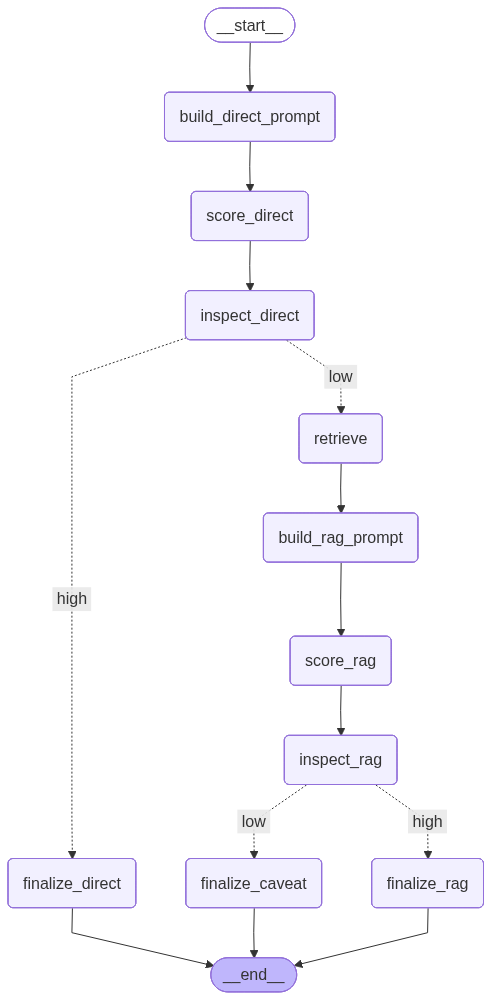

In [11]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    # draw_mermaid_png() calls the mermaid.ink web service; fall back to ASCII
    # if there's no network or the service is unreachable.
    print(f"Mermaid PNG unavailable ({e}); using ASCII fallback:\n")
    print(agent.get_graph().draw_ascii())


## 6. Run the agent

Three questions chosen to exercise each routing path:

1. **A well-known fact** — the LLM is highly consistent, so the agent finalizes
   from the direct branch without paying for retrieval.
2. **A niche fact in our corpus** — the direct answer's min-token probability
   is low, retrieval finds the relevant passage, and the re-scored answer
   crosses the threshold (the *rescue* case).
3. **A fact not in the corpus and not in the model's knowledge** — neither
   branch reaches confidence, so the agent returns the answer with an explicit
   caveat instead of pretending.

For the RAG and caveat paths the printout shows both the **initial** direct-path
confidence and the **final** confidence after retrieval.

In [12]:
import time


async def ask(question: str) -> AgentState:
    """Run the agent and pretty-print the result + wall-clock latency."""
    t0 = time.perf_counter()
    result = await agent.ainvoke({"question": question})
    elapsed = time.perf_counter() - t0
    print(f"Q: {question}")
    print(f"PATH:       {result['path']}")
    # Only the direct branch sets a single confidence value; the RAG and caveat
    # branches expose the initial direct-path score too so the rescue (or lack
    # thereof) is visible at a glance.
    if result["path"] == "direct":
        print(f"CONFIDENCE: {result['confidence']:.3f}")
    else:
        print(f"INITIAL CONFIDENCE: {result['initial_confidence']:.3f}  (direct path)")
        print(f"FINAL CONFIDENCE:   {result['confidence']:.3f}  (after retrieval)")
    print(f"LATENCY:    {elapsed:.2f}s")
    print(f"ANSWER:     {result['final_answer']}")
    print("TRACE:")
    for step in result.get("trace", []):
        print(f"  {step}")
    print("-" * 80)
    return result


In [13]:
result1 = await ask("What is the largest planet in our solar system?")


Q: What is the largest planet in our solar system?
PATH:       direct
CONFIDENCE: 0.991
LATENCY:    3.07s
ANSWER:     The largest planet in our solar system is Jupiter.
TRACE:
  {'node': 'score_direct', 'score': np.float64(0.991), 'answer': 'The largest planet in our solar system is Jupiter.'}
--------------------------------------------------------------------------------


In [14]:
result2 = await ask(
    "What foraging technique does the aye-aye use to find insect larvae?"
)


Q: What foraging technique does the aye-aye use to find insect larvae?
PATH:       rag
INITIAL CONFIDENCE: 0.356  (direct path)
FINAL CONFIDENCE:   0.780  (after retrieval)
LATENCY:    2.59s
ANSWER:     The aye-aye uses a foraging technique called percussive foraging to find insect larvae. This involves tapping on trees and listening for echoes that signal hollows inside them, which are often infested by grubs.
TRACE:
  {'node': 'score_direct', 'score': np.float64(0.356), 'answer': 'The aye-aye uses a technique called "percussive foraging," where it taps on tree bark to locate insect larvae and then uses its elongated middle finger to extract them from the wood.'}
  {'node': 'retrieve', 'retrieved': [{'id': 'Aye-aye#5', 'score': 0.766}, {'id': 'Aye-aye#0', 'score': 0.607}]}
  {'node': 'score_rag', 'score': np.float64(0.78), 'answer': 'The aye-aye uses a foraging technique called percussive foraging to find insect larvae. This involves tapping on trees and listening for echoes that sign

In [15]:
result3 = await ask(
    "What was the average daily rainfall in millimetres in the village of "
    "Snargate, Kent during March 2024?"
)


Q: What was the average daily rainfall in millimetres in the village of Snargate, Kent during March 2024?
PATH:       caveat
INITIAL CONFIDENCE: 0.294  (direct path)
FINAL CONFIDENCE:   0.469  (after retrieval)
LATENCY:    2.31s
ANSWER:     The context provided does not contain any information about the average daily rainfall in millimetres in the village of Snargate, Kent during March 2024. Therefore, I cannot answer the question.

[Low confidence: the model's minimum-token probability remained below 0.5 even after retrieval (initial=0.29, final=0.47). Please verify before acting on this response.]
TRACE:
  {'node': 'score_direct', 'score': np.float64(0.294), 'answer': "I'm sorry, but I don't have access to weather data for March 2024."}
  {'node': 'retrieve', 'retrieved': [{'id': 'Madagascar#10', 'score': 0.304}, {'id': 'Antikythera mechanism#5', 'score': 0.215}]}
  {'node': 'score_rag', 'score': np.float64(0.469), 'answer': 'The context provided does not contain any information abou

## 7. Key findings

Three questions, three different routing decisions — all driven by a single
confidence threshold at zero LLM-cost overhead.

| # | Question | Path | Score(s) | Outcome |
|---|---|---|---|---|
| 1 | *"What is the largest planet in our solar system?"* | `direct` | 0.991 | High-confidence answer; retrieval skipped (1 LLM call, not 2). |
| 2 | *"What foraging technique does the aye-aye use…?"* | `rag` (rescue) | 0.356 → 0.780 | Model hedged on tokens; retrieval grounded the answer. |
| 3 | *"…rainfall in Snargate, Kent in March 2024?"* | `caveat` | 0.294 → 0.469 | Out-of-corpus and unknown; returned with explicit warning. |

### Takeaways

- **White-box scoring is essentially free.** `WhiteBoxUQ(min_probability)` reads
  the logprobs the model already produces — no extra LLM calls per scoring
  node. Compare to a sampling-based scorer like `BlackBoxUQ`, which costs
  N + 1 calls per score.
- **One number → non-trivial agent control flow.** A single 0.5 threshold
  separates three qualitatively different behaviors: confident direct answer,
  RAG-rescued answer, and caveated low-confidence response.
- **RAG is not a hallucination silver bullet.** Q3 shows the agent producing an
  answer *after* retrieval that's still low-confidence — the retriever pulled
  irrelevant context (Madagascar, Antikythera mechanism), and the model's
  token-level uncertainty surfaces that. The numeric gate catches it; a
  consumer reading "the context does not contain the answer" as free-form text
  would have to NLI-parse the refusal.
- **The integration is a one-line plug-in.** `make_uqlm_node(scorer)` returns
  a LangGraph-compatible async node that reads the prompt from state and
  writes the score back. No glue code, no custom wrapper.

© 2026 CVS Health and/or one of its affiliates. All rights reserved.